In [11]:
import sys 
import os

sys.path.append(os.path.abspath('..'))
import torch
import torch.nn as nn
from torchvision import models
from lib.data.dataset import BeeDataset
from lib.data.preprocessing import TorchPreprocessor
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from lib.data.train_val_split import train_val_split
from lib.data.data_augmentation import data_augmented_loader

In [12]:
batch_size = 64

num_classes = 50

device = 'cuda' if torch.cuda.is_available() else 'cpu'

lr= 0.01
epochs = 10
weight_decay = 0

In [13]:
resnet_processor_parameters = {
    "mean": [0.485, 0.456, 0.406],
    "std": [0.229, 0.224, 0.225],
    "crop_size": (224, 224)
}

# transforme = TorchPreprocessor(
#     normalize=True,
#     mean=resnet_processor_parameters["mean"],
#     std=resnet_processor_parameters["std"],
#     resize_method="pad",      # ou "resize" selon ton pipeline
#     target_size=resnet_processor_parameters["crop_size"],
# )

In [14]:
# root_dir = '../data/train'
# # transforme = TorchPreprocessor(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

# # dataset = BeeDataset(train= True, transform = transforme)

# train_dataset, val_dataset = train_val_split(transforme)

# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

train_loader, val_loader = data_augmented_loader(mean=resnet_processor_parameters["mean"],
    std=resnet_processor_parameters["std"])


# n_total = len(dataset)

# n_train = int(0.80 * n_total)
# n_test = int(0.15 * n_total)
# n_val =  int(n_total - n_train - n_test)
# train_dataset, test_dataset, val_dataset = torch.utils.data.random_split(
#     dataset,
#     [n_train, n_test, n_val],
#     generator=torch.Generator().manual_seed(42)

# )


# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
# test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

Train prêt : 6417 images (avec augmentation)
Val prête  : 1582 images (sans augmentation)


In [15]:
class ResnetFineTune (nn.Module):
    def __init__(self, num_classes):
        super(ResnetFineTune, self).__init__()

        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
           
        for param in self.resnet.parameters():
            param.requires_grad = False

        for param in self.resnet.layer4.parameters():
            param.requires_grad = True

        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Linear(in_features, num_classes)

    def forward (self, x):
        

        return self.resnet(x)
    
    def inference(self, x):
        self.eval()
        with torch.no_grad():
            logits = self(x)
            probs = torch.softmax(logits, dim=1)
            pred_class = torch.argmax(probs, dim=1).item()
        
        return pred_class + 1

In [16]:
class EfficientnetFineTune (nn.Module):
    def __init__(self, num_classes):
        super(EfficientnetFineTune, self).__init__()

        self.model = models.efficientnet_b3(weights="IMAGENET1K_V1")

        # Geler les couches de base (optionnel — à décommenter si peu de données)
        for param in self.model.features.parameters():
            param.requires_grad = False

        # Remplacer la tête de classification
        in_features = self.model.classifier[1].in_features
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(in_features, num_classes),
        )

    def forward (self, x):
        

        return self.model(x)
    
    def inference(self, x):
        self.eval()
        with torch.no_grad():
            logits = self(x)
            probs = torch.softmax(logits, dim=1)
            pred_class = torch.argmax(probs, dim=1).item()
        
        return pred_class + 1

In [17]:
class WideResNet101FineTune(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.wide_resnet101_2(weights=models.Wide_ResNet101_2_Weights.DEFAULT)

        for param in self.model.parameters():
            param.requires_grad = False

        for param in self.model.layer4.parameters():
            param.requires_grad = True

        in_features = self.model.fc.in_features
        self.model.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)

    def inference(self, x):
        self.eval()
        with torch.no_grad():
            logits = self(x)
            probs = torch.softmax(logits, dim=1)
            pred_class = torch.argmax(probs, dim=1)
        return pred_class + 1

In [18]:
class InceptionV3FineTune(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT, aux_logits=False)

        for param in self.model.parameters():
            param.requires_grad = False

        # Dé-geler dernier bloc
        for param in self.model.Mixed_7c.parameters():  # dernier bloc
            param.requires_grad = True

        in_features = self.model.fc.in_features
        self.model.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        # InceptionV3 attend des images >= 299x299
        return self.model(x)

    def inference(self, x):
        self.eval()
        with torch.no_grad():
            logits = self(x)
            probs = torch.softmax(logits, dim=1)
            pred_class = torch.argmax(probs, dim=1)
        return pred_class + 1

In [19]:
class MnasNetA1FineTune(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.mnasnet1_0(weights=models.MNASNet1_0_Weights.DEFAULT)

        for param in self.model.parameters():
            param.requires_grad = False

        # Dé-geler le dernier bloc (features[-1])
        for param in self.model.layers[-1].parameters():
            param.requires_grad = True

        in_features = self.model.classifier[1].in_features
        self.model.classifier[1] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)

    def inference(self, x):
        self.eval()
        with torch.no_grad():
            logits = self(x)
            probs = torch.softmax(logits, dim=1)
            pred_class = torch.argmax(probs, dim=1)
        return pred_class + 1

In [20]:
class EarlyStopping:
    
    def __init__(self, patience=5, delta=0):
        self.patience = patience
        self.counter = 0
        self.best_score = None
        self.delta = delta
        self.early_stop = False

    def step(self, val_loss):
        """Step of the early stopping monitoring when to stop depending on the loss and the patience
        
        Args:
            val_loss (float) : loss value of the validation set at the epoch
        """
        
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.delta:
            self.counter += 1
            print('EarlyStopping counter: %d / %d' % (self.counter, self.patience))
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.counter = 0

In [21]:
def training_CTC(device, lr, epochs, weight_decay , train_loader, val_loader, earlystopping = True):
    """
    Training of our model using CTC loss. We can add weight noise, earlystopping and choose between SGD or Adam

    Args:
        device (torch.device) : cpu or gpu
        lr (float) : learning rate of the optimizer
        train_loader (Dataloader) : dataloader of the training data
        val_loader (Dataloader) : dataloader of the validation data
        momentum (float) : momentum for the SGD optimiser
        noise (bool) : choose if we add weight noise or not
        earlystopping (bool) : choose if we add earlystopping or not
        adam (bool) : choose if we use Adam or SGD

    Returns:
        model (nn.Module) : trained model
        loss_train (list) : list of the training loss averaged on each batch 
        loss_val (list) : list of the validation loss averaged on each batch
    
    """

    # Initialisation of the model, loss function and optimiser

    model = ResnetFineTune(num_classes).to(device)

    optimizer = optim.Adam(model.parameters(), lr, weight_decay= weight_decay)

    criterion = nn.CrossEntropyLoss()



    if earlystopping:
        estop = EarlyStopping(patience=50) # If we want early stopping, we initialise it with a patience of 20

    loss_train, loss_val = [], []

    for epoch in range(1, epochs + 1):
        
        model.train()

        temp_loss= []

        for X_batch, labels in train_loader:

            labels = labels.long().to(device)
            X_batch = X_batch.float().to(device)
            y_pred = model(X_batch).to(device) #Prediction des positions

            loss = criterion(y_pred, labels) #Calcule de la fonction de perte 

            #Methode des gradiens
            optimizer.zero_grad()
            loss = loss.float()
            loss.backward()
            optimizer.step()

            temp_loss.append(loss.cpu().detach().numpy())
        
        loss_train.append(np.mean(np.array(temp_loss)))

        model.eval()
        with torch.no_grad():
            
            temp_loss_val = []
            for X_val, labels_val in val_loader:


                labels_val = labels_val.float().to(device)
                X_val = X_val.float().to(device)
                y_val = model(X_val).to(device) #Prediction des positions

                val_loss = criterion(y_val, labels_val) #Calcule de la fonction de perte



                temp_loss_val.append(val_loss.cpu().detach().numpy())
                    
        loss_val.append(np.mean(np.array(temp_loss_val))) # At each epoch, we add the mean loss of all the validation data


        if epoch % 10 == 0:
            print("Epoch %d: train loss %.4f, val loss %.4f" % (epoch, loss.detach().item(), val_loss.detach().item()))
        
        if earlystopping:
            estop.step(val_loss)
        if earlystopping and estop.early_stop: # Stop the training if the early stopping has exeeded the patience
            break

    return model, loss_train, loss_val


In [22]:
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import f1_score

def training_CTC(device, lr, epochs, weight_decay, train_loader, val_loader, num_classes):
    """
    Training of our model using CrossEntropy loss with tqdm and F1-score per epoch.

    Args:
        device (torch.device) : cpu or gpu
        lr (float) : learning rate of the optimizer
        epochs (int) : number of epochs
        weight_decay (float) : weight decay for optimizer
        train_loader (DataLoader) : dataloader of the training data
        num_classes (int) : number of output classes

    Returns:
        model (nn.Module) : trained model
        loss_train (list) : training loss per epoch
        f1_train_list (list) : F1-score per epoch
    """

    # Initialisation of the model, loss function and optimiser
    model = ResnetFineTune(num_classes).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    # scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    #     optimizer,
    #     mode='min',        
    #     factor=0.5,         
    #     patience=3
    # )

    loss_train, loss_val = [], []
    f1_train_list = []

    for epoch in range(1, epochs + 1):
        model.train()
        temp_loss = []
        all_preds = []
        all_labels = []

        loop = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", leave=False)
        for X_batch, labels in loop:
            labels = labels.long().to(device)
            X_batch = X_batch.float().to(device)

            optimizer.zero_grad()
            y_pred = model(X_batch)

            loss = criterion(y_pred, labels)
            loss.backward()
            optimizer.step()

            temp_loss.append(loss.item())
            
            # Update tqdm description with current loss
            loop.set_postfix(loss=np.mean(temp_loss))

               
        avg_loss = np.mean(temp_loss)
        loss_train.append(avg_loss)

        model.eval()
        with torch.no_grad():
            
            temp_loss_val = []
            for X_val, labels_val in val_loader:


                labels_val = labels_val.long().to(device)
                X_val = X_val.float().to(device)
                y_val = model(X_val).to(device) #Prediction des positions

                val_loss = criterion(y_val, labels_val) #Calcule de la fonction de perte


                # scheduler.step(val_loss) 

                temp_loss_val.append(val_loss.cpu().detach().numpy())
                    
                # Collect predictions for F1
                preds = torch.argmax(y_val, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels_val.cpu().numpy())


        loss_val.append(np.mean(np.array(temp_loss_val))) # At each epoch, we add the mean loss of all the validation data
        
            




        # Compute F1-score for the epoch
        f1_epoch = f1_score(all_labels, all_preds, average='macro')
        f1_train_list.append(f1_epoch)

        print(f"Epoch {epoch}/{epochs} - Loss: {avg_loss:.4f} - F1: {f1_epoch:.4f}")

    return model, loss_train, loss_val,  f1_train_list

In [ ]:
# model, loss_train, loss_val = training_CTC(device, lr, epochs, weight_decay, train_loader, train_loader, earlystopping = False)
model, loss_train, loss_val, f1_train_list = training_CTC(device, lr, epochs, weight_decay, train_loader, val_loader, num_classes)

Epoch 1/10:  21%|██        | 42/201 [00:30<02:02,  1.30it/s, loss=4.97]

NameError: name 'loss_val' is not defined

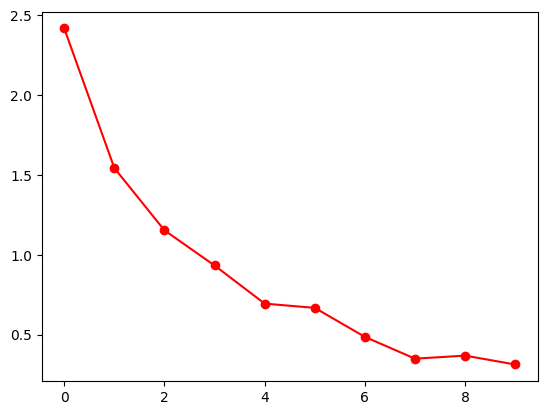

In [ ]:
plt.plot(loss_train, 'r' , marker='o', linestyle='-', label = 'loss_train')
plt.plot(loss_val, 'b' , marker='o', linestyle='-', label = 'loss_test')
plt.xlabel('Points')
plt.ylabel('Loss fonction')
plt.grid()
plt.legend()
plt.show()

In [ ]:
def submission(model, X_test):
    pred = []
    for img in X_test:

        img = img[0].unsqueeze(0).to(device)  
        pred.append(model.inference(img))

    df = pd.DataFrame({
        "id": range(len(pred)),
        "label": pred
    })

    df.to_csv("submission3.csv", index=False)




In [ ]:
test_dataset = BeeDataset(train = False, transform = transforme)

In [ ]:
submission(model, test_dataset)

In [ ]:
from transformers import ViTForImageClassification, ViTImageProcessor 


model_name = "google/vit-base-patch16-224"
feature_extractor = ViTImageProcessor.from_pretrained(model_name)
model = ViTForImageClassification.from_pretrained(model_name, 
                                                   num_labels=10,  # nombre d'espèces
                                                   ignore_mismatched_sizes=True)

# Inférence sur une image
inputs = []
for img, _ in test_dataset:
    inputs.append(feature_extractor(images=img, return_tensors="pt"))
outputs = model(inputs)
logits = outputs.logits
predicted_class = logits.argmax(-1).item()

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([10])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


ValueError: The image to be converted to a PIL image contains values outside the range [0, 1], got [-2.0851547718048096, 2.519804000854492] which cannot be converted to uint8.